# Exploratory Data Analysis (EDA)

Первичное исследование данных: структура, типы, пропуски, распределения, корреляции.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

data_dir = os.path.join('..', 'data')

train = pd.read_csv(os.path.join(data_dir, 'train.csv'), parse_dates=['date'])
test = pd.read_csv(os.path.join(data_dir, 'test.csv'), parse_dates=['date'])
stores = pd.read_csv(os.path.join(data_dir, 'stores.csv'))
oil = pd.read_csv(os.path.join(data_dir, 'oil.csv'), parse_dates=['date'])
holidays = pd.read_csv(os.path.join(data_dir, 'holidays_events.csv'), parse_dates=['date'])
transactions = pd.read_csv(os.path.join(data_dir, 'transactions.csv'), parse_dates=['date'])

train = train.drop(columns=['id'])
test = test.drop(columns=['id'])

train['family'] = train['family'].astype('category')
test['family'] = test['family'].astype('category')

print('All data loaded. Column `id` dropped. `family` cast to category.')
print(f'Train memory: {train.memory_usage(deep=True).sum() / 1e6:.1f} MB')

All data loaded. Column `id` dropped. `family` cast to category.
Train memory: 99.0 MB


### Обзор таблицы `train`

In [2]:
print(f'Train shape: {train.shape}')
print(f'Date range: {train["date"].min()} — {train["date"].max()}')
print(f'Unique stores: {train["store_nbr"].nunique()}, Unique families: {train["family"].nunique()}')
display(train.head())
train[['sales', 'onpromotion']].describe()

Train shape: (3000888, 5)
Date range: 2013-01-01 00:00:00 — 2017-08-15 00:00:00
Unique stores: 54, Unique families: 33


,date,store_nbr,family,sales,onpromotion
0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,2013-01-01,1,BABY CARE,0.0,0
2,2013-01-01,1,BEAUTY,0.0,0
3,2013-01-01,1,BEVERAGES,0.0,0
4,2013-01-01,1,BOOKS,0.0,0


,sales,onpromotion
count,3.000888e+06,3.000888e+06
mean,3.577757e+02,2.602770e+00
std,1.101998e+03,1.221888e+01
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,1.100000e+01,0.000000e+00
75%,1.958473e+02,0.000000e+00
max,1.247170e+05,7.410000e+02


### Обзор таблицы `stores`

In [3]:
print(f'Stores shape: {stores.shape}')
display(stores.head())
print(f'\nCities: {stores["city"].nunique()}, States: {stores["state"].nunique()}, Types: {stores["type"].nunique()}, Clusters: {stores["cluster"].nunique()}')
display(stores['type'].value_counts())

Stores shape: (54, 5)


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4



Cities: 22, States: 16, Types: 5, Clusters: 17


type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64

### Анализ пропусков по всем таблицам

In [4]:
print('=== train ===')
display(train.isna().sum())
print('\n=== test ===')
display(test.isna().sum())
print('\n=== oil ===')
display(oil.isna().sum())
print(f'  -> {oil["dcoilwtico"].isna().mean()*100:.1f}% пропусков в ценах на нефть')
print('\n=== holidays ===')
display(holidays.isna().sum())
print('\n=== transactions ===')
display(transactions.isna().sum())

=== train ===


date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


=== test ===


date           0
store_nbr      0
family         0
onpromotion    0
dtype: int64


=== oil ===


date           0
dcoilwtico    43
dtype: int64

  -> 3.5% пропусков в ценах на нефть

=== holidays ===


date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64


=== transactions ===


date            0
store_nbr       0
transactions    0
dtype: int64

### Анализ нулевых продаж

In [5]:
zero_sales = (train['sales'] == 0).sum()
zero_pct = zero_sales / len(train) * 100
print(f'Нулевых продаж: {zero_sales:,} из {len(train):,} ({zero_pct:.1f}%)')
print('\nДоля нулей по топ-10 категориям:')
display(
    train.groupby('family')['sales']
    .apply(lambda x: (x == 0).mean() * 100)
    .sort_values(ascending=False)
    .head(10)
    .round(1)
    .rename('zero_pct')
)

Нулевых продаж: 939,130 из 3,000,888 (31.3%)

Доля нулей по топ-10 категориям:


C:\Users\tyrys\AppData\Local\Temp\ipykernel_21996\4023087881.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby('family')['sales']


family
BOOKS                         97.0
BABY CARE                     94.1
SCHOOL AND OFFICE SUPPLIES    74.1
HOME APPLIANCES               73.5
LADIESWEAR                    59.8
MAGAZINES                     56.5
PET SUPPLIES                  54.6
HARDWARE                      47.9
LAWN AND GARDEN               46.8
PLAYERS AND ELECTRONICS       44.9
Name: zero_pct, dtype: float64

### Покрытие дат: train vs test

Проверяем временные диапазоны, наличие "дыр" в датах и совпадение магазинов/категорий.

In [6]:
print('--- Train ---')
print(f'  Даты: {train["date"].min()} — {train["date"].max()}')
print(f'  Уникальных дат: {train["date"].nunique()}')
print(f'  Ожидаемых дней: {(train["date"].max() - train["date"].min()).days + 1}')

print('\n--- Test ---')
print(f'  Даты: {test["date"].min()} — {test["date"].max()}')
print(f'  Уникальных дат: {test["date"].nunique()}')
print(f'  Ожидаемых дней: {(test["date"].max() - test["date"].min()).days + 1}')

full_range = pd.date_range(train['date'].min(), train['date'].max())
missing_dates = full_range.difference(train['date'].unique())
print(f'\nПропущенных дат в train: {len(missing_dates)}')
if len(missing_dates) > 0:
    print(f'  Первые 10: {list(missing_dates[:10])}')

print(f'\nМагазины в train: {sorted(train["store_nbr"].unique())}')
print(f'Магазины в test:  {sorted(test["store_nbr"].unique())}')
print(f'Совпадение: {set(train["store_nbr"].unique()) == set(test["store_nbr"].unique())}')

--- Train ---
  Даты: 2013-01-01 00:00:00 — 2017-08-15 00:00:00


  Уникальных дат: 1684


  Ожидаемых дней: 1688

--- Test ---
  Даты: 2017-08-16 00:00:00 — 2017-08-31 00:00:00
  Уникальных дат: 16
  Ожидаемых дней: 16

Пропущенных дат в train: 4
  Первые 10: [Timestamp('2013-12-25 00:00:00'), Timestamp('2014-12-25 00:00:00'), Timestamp('2015-12-25 00:00:00'), Timestamp('2016-12-25 00:00:00')]

Магазины в train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(

### Обзор таблицы `oil`

Shape of oil: (1218, 2)


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1218 non-null   datetime64[ns]
 1   dcoilwtico  1175 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.2 KB


None

,date,dcoilwtico
count,1218,1175.000000
mean,2015-05-02 12:00:00,67.714366
min,2013-01-01 00:00:00,26.190000
25%,2014-03-03 06:00:00,46.405000
50%,2015-05-02 12:00:00,53.190000
75%,2016-06-30 18:00:00,95.660000
max,2017-08-31 00:00:00,110.620000
std,NaN,25.630476


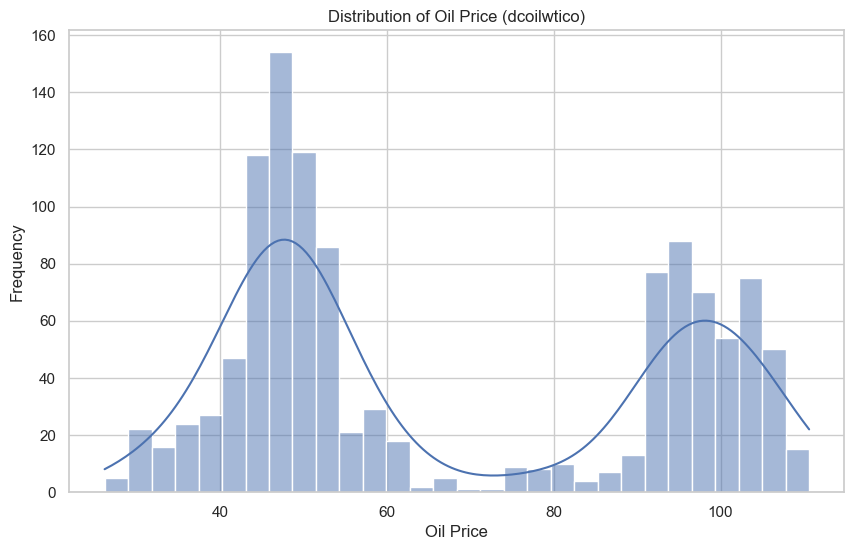

In [7]:
print(f"Shape of oil: {oil.shape}")
display(oil.head())
display(oil.info())
display(oil.describe())

plt.figure(figsize=(10, 6))
sns.histplot(oil['dcoilwtico'].dropna(), kde=True, bins=30)
plt.title('Distribution of Oil Price (dcoilwtico)')
plt.xlabel('Oil Price')
plt.ylabel('Frequency')
plt.show()

### Обзор таблицы `holidays`

In [8]:
print(f"Shape of holidays: {holidays.shape}")
display(holidays.head())
display(holidays.info())
display(holidays.describe())

Shape of holidays: (350, 6)


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         350 non-null    datetime64[ns]
 1   type         350 non-null    object        
 2   locale       350 non-null    object        
 3   locale_name  350 non-null    object        
 4   description  350 non-null    object        
 5   transferred  350 non-null    bool          
dtypes: bool(1), datetime64[ns](1), object(4)
memory usage: 14.1+ KB


None

,date
count,350
mean,2015-04-24 00:45:15.428571392
min,2012-03-02 00:00:00
25%,2013-12-23 06:00:00
50%,2015-06-08 00:00:00
75%,2016-07-03 00:00:00
max,2017-12-26 00:00:00


### Корреляция числовых признаков с `sales`

Только `sales` и `onpromotion` — осмысленные числовые переменные. `store_nbr` — категориальный ID.

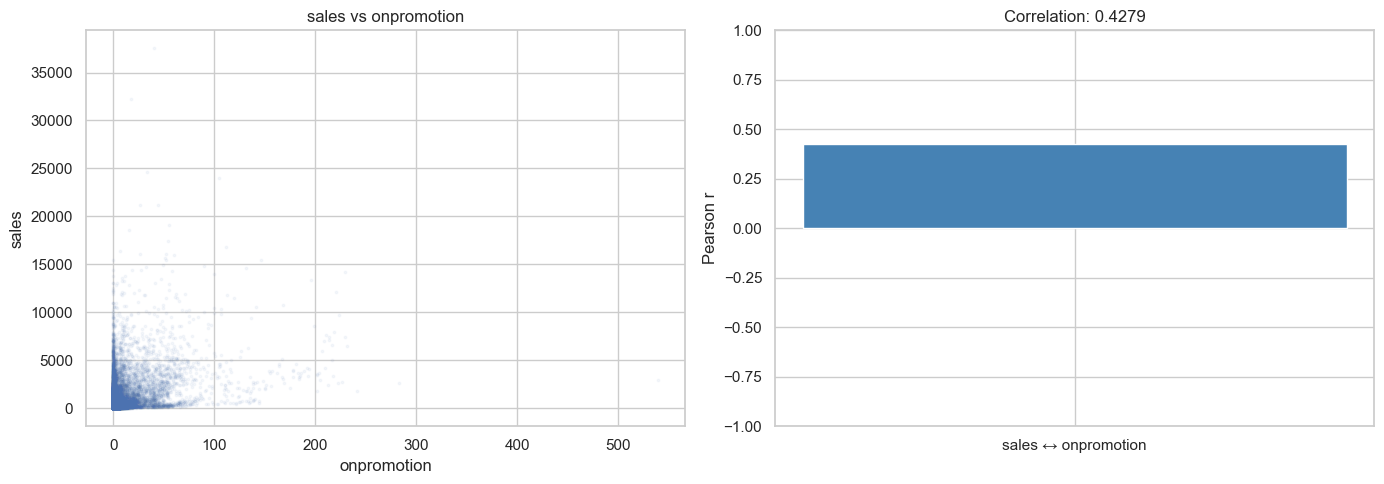

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_title('sales vs onpromotion')
sampled = train.sample(50_000, random_state=42)
axes[0].scatter(sampled['onpromotion'], sampled['sales'], alpha=0.05, s=3)
axes[0].set_xlabel('onpromotion')
axes[0].set_ylabel('sales')

corr_val = train['sales'].corr(train['onpromotion'])
axes[1].bar(['sales ↔ onpromotion'], [corr_val], color='steelblue')
axes[1].set_ylabel('Pearson r')
axes[1].set_title(f'Correlation: {corr_val:.4f}')
axes[1].set_ylim(-1, 1)

plt.tight_layout()
plt.show()

### Выбросы в `sales`

C:\Users\tyrys\AppData\Local\Temp\ipykernel_21996\4168737124.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_families = train.groupby('family')['sales'].mean().nlargest(10).index


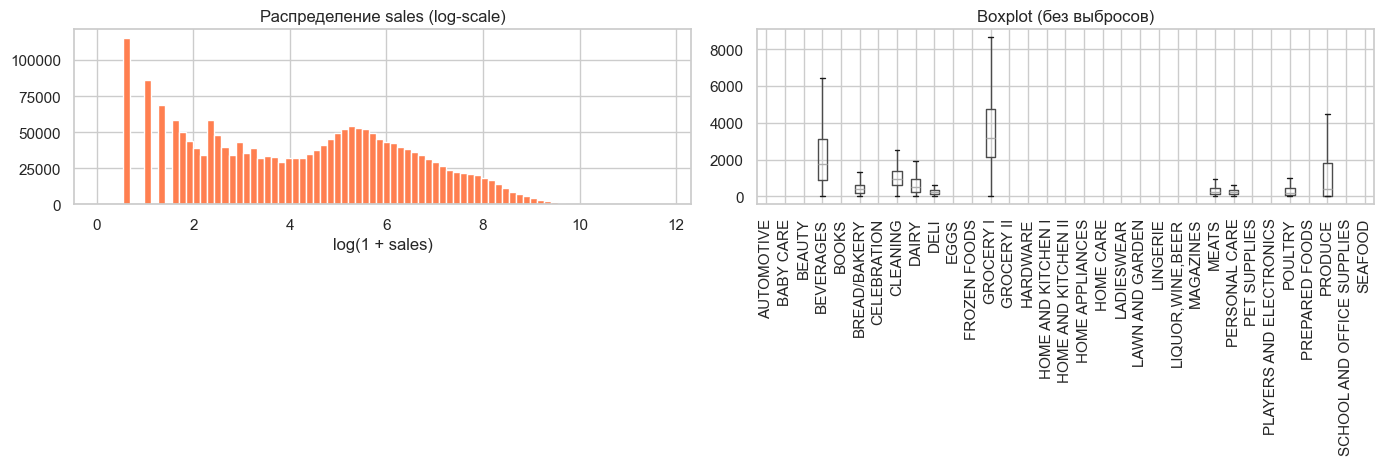


Max sales: 124,717
99-й перцентиль: 5,507
Медиана: 11


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_title('Распределение sales (log-scale)')
train.loc[train['sales'] > 0, 'sales'].apply(np.log1p).hist(bins=80, ax=axes[0], color='coral')
axes[0].set_xlabel('log(1 + sales)')

top_families = train.groupby('family')['sales'].mean().nlargest(10).index
axes[1].set_title('Топ-10 категорий по средним продажам')
train[train['family'].isin(top_families)].boxplot(
    column='sales', by='family', ax=axes[1], rot=90, showfliers=False
)
axes[1].set_title('Boxplot (без выбросов)')
axes[1].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

print(f'\nMax sales: {train["sales"].max():,.0f}')
print(f'99-й перцентиль: {train["sales"].quantile(0.99):,.0f}')
print(f'Медиана: {train["sales"].median():,.0f}')

### Обзор таблицы `transactions`

In [11]:
print(f"Shape of transactions: {transactions.shape}")
display(transactions.head())
display(transactions.info())
display(transactions.describe())

Shape of transactions: (83488, 3)


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          83488 non-null  datetime64[ns]
 1   store_nbr     83488 non-null  int64         
 2   transactions  83488 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.9 MB


None

,date,store_nbr,transactions
count,83488,83488.000000,83488.000000
mean,2015-05-20 16:07:40.866232064,26.939237,1694.602158
min,2013-01-01 00:00:00,1.000000,5.000000
25%,2014-03-27 00:00:00,13.000000,1046.000000
50%,2015-06-08 00:00:00,27.000000,1393.000000
75%,2016-07-14 06:00:00,40.000000,2079.000000
max,2017-08-15 00:00:00,54.000000,8359.000000
std,NaN,15.608204,963.286644
